# 07 — Agente RAG con LangGraph

**Proyecto:** Chem RAG Assistant  
**Repositorio:** https://github.com/Jesusrodriguezf90/chem-rag-assistant  
**Fase:** Agentic RAG — prototipo

---

Este notebook implementa un agente RAG con LangGraph que supera las limitaciones
del pipeline RAG lineal. El agente decide de forma autónoma si recuperar del
ChromaDB, responder con conocimiento general, o reescribir la query y reintentar.

In [5]:
"""
Notebook: 07_agente.ipynb

Objetivo:
    Implementar un agente RAG con LangGraph que supera las limitaciones
    del pipeline RAG lineal construido en los notebooks anteriores.

    A diferencia del RAG clásico (recuperar → generar, siempre),
    este agente decide de forma autónoma en cada consulta:
      - Si la pregunta requiere información específica del paper → ChromaDB
      - Si puede responderse con conocimiento general de química → respuesta directa
      - Si los chunks recuperados no son relevantes → reescribir query y reintentar

    El patrón implementado es Adaptive RAG + Corrective RAG — el estándar
    de la industria en 2026 para sistemas RAG de producción.

    Arquitectura del grafo:

      Query
        ↓
      Router  (LLM clasifica: paper_especifico / general / fuera_dominio)
        ↓                    ↓                        ↓
      Retriever          Generator               Generator
        ↓               (conocimiento            (respuesta
      Grader              general)                directa)
        ↓ no relevante  ↓ relevante
      Rewriter         Generator
        ↓
      Retriever (máx 2 intentos)

    Este notebook cubre:
      1. Configuración del entorno
      2. Instalación de dependencias
      3. Carga de ChromaDB e inicialización de componentes
      4. Definición del estado del grafo
      5. Implementación de los nodos
      6. Construcción y compilación del grafo
      7. Evaluación con preguntas de prueba
      8. Resumen final

    Siguiente paso:
      Migración a src/agent/graph.py y exposición como endpoint
      POST /agent_query en la API FastAPI.

Fuente de datos:
    Büchele WRE, Schlachta TP, Gebendorfer AL, Pamperin J, Richter LF,
    Sauer MJ, Prokop A, Kühn FE. Synthesis, characterization, and biomedical
    evaluation of ethylene-bridged tetra-NHC Pd(ii), Pt(ii) and Au(iii)
    complexes, with apoptosis-inducing properties in cisplatin-resistant
    neuroblastoma cells. Frontiers in Chemistry. 2024.
    PMC: https://pmc.ncbi.nlm.nih.gov/articles/PMC10967698/

    Documento utilizado exclusivamente con fines de investigación y desarrollo.
    No se distribuye ni se incluye en el repositorio.

Autor:   Jesús Rodríguez
Fecha:   2026-05-21
Versión: 1.0.0
"""

'\nNotebook: 07_agente.ipynb\n\nObjetivo:\n    Implementar un agente RAG con LangGraph que supera las limitaciones\n    del pipeline RAG lineal construido en los notebooks anteriores.\n\n    A diferencia del RAG clásico (recuperar → generar, siempre),\n    este agente decide de forma autónoma en cada consulta:\n      - Si la pregunta requiere información específica del paper → ChromaDB\n      - Si puede responderse con conocimiento general de química → respuesta directa\n      - Si los chunks recuperados no son relevantes → reescribir query y reintentar\n\n    El patrón implementado es Adaptive RAG + Corrective RAG — el estándar\n    de la industria en 2026 para sistemas RAG de producción.\n\n    Arquitectura del grafo:\n\n      Query\n        ↓\n      Router  (LLM clasifica: paper_especifico / general / fuera_dominio)\n        ↓                    ↓                        ↓\n      Retriever          Generator               Generator\n        ↓               (conocimiento            (r

## 1. Configuración del entorno

In [6]:
# Librería estándar
import json
import os
import re
import sys
from pathlib import Path
from typing import Literal, TypedDict, Annotated

print(f'Python version: {sys.version}')

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [7]:
# Verificar disponibilidad de GPU — no es obligatoria para el agente
# BGE-M3 y ChromaDB funcionan en CPU, aunque con mayor latencia
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

if DEVICE == 'cuda':
    print(f'GPU detectada: {torch.cuda.get_device_name(0)}')
    print(f'VRAM total   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('GPU no detectada — el agente funcionará en CPU')

print(f'Dispositivo activo: {DEVICE}')

GPU no detectada — el agente funcionará en CPU
Dispositivo activo: cpu


In [8]:
from google.colab import drive, userdata
drive.mount('/content/drive')

PROYECTO_RAIZ  = Path('/content/drive/MyDrive/chem-rag-assistant')
DIR_CHROMA     = PROYECTO_RAIZ / 'data' / 'chroma_db'
DIR_EMBEDDINGS = PROYECTO_RAIZ / 'data' / 'embeddings'

assert DIR_CHROMA.exists(), f'ChromaDB no encontrada en {DIR_CHROMA}'

print(f'Proyecto raíz : {PROYECTO_RAIZ}')
print(f'ChromaDB      : {DIR_CHROMA}')

Mounted at /content/drive
Proyecto raíz : /content/drive/MyDrive/chem-rag-assistant
ChromaDB      : /content/drive/MyDrive/chem-rag-assistant/data/chroma_db


In [9]:
# Cargar token HF desde los secretos de Colab
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    assert HF_TOKEN, 'Token vacío en secretos'
    print('HF_TOKEN cargado desde secretos de Colab.')
except Exception:
    HF_TOKEN = os.getenv('HF_TOKEN', '')
    print('HF_TOKEN cargado desde variable de entorno.')

assert HF_TOKEN, 'HF_TOKEN no encontrado. Añádelo en Colab → Secrets.'

# Modelos utilizados por el agente
MODELO_LLM   = 'Qwen/Qwen3-8B'    # Router, Grader, Rewriter y Generator
MODELO_EMBED = 'BAAI/bge-m3'       # Embeddings para recuperación
COLECCION    = 'chem_rag_pmc10967698'          # Nombre de la colección en ChromaDB

print(f'LLM          : {MODELO_LLM}')
print(f'Embeddings   : {MODELO_EMBED}')
print(f'Colección    : {COLECCION}')

HF_TOKEN cargado desde secretos de Colab.
LLM          : Qwen/Qwen3-8B
Embeddings   : BAAI/bge-m3
Colección    : chem_rag_pmc10967698


## 2. Instalación de dependencias

In [10]:
# Dependencias para el agente LangGraph
# langgraph: orquestación del grafo de agentes con estado persistente
# langchain-core: contratos base de LangChain (mensajes, prompts, herramientas)
# chromadb: base de datos vectorial para recuperación semántica
# FlagEmbedding: modelo de embeddings BGE-M3
# huggingface_hub: InferenceClient para llamadas a Qwen3-8B
!pip install langgraph langchain-core chromadb FlagEmbedding huggingface_hub --quiet
print('Dependencias instaladas.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [11]:
# Imports de las librerías del agente
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from FlagEmbedding import BGEM3FlagModel
from huggingface_hub import InferenceClient
import chromadb
import numpy as np

print('Imports completados correctamente.')

Imports completados correctamente.


## 3. Carga de ChromaDB e inicialización de componentes

In [12]:
# Cargar el modelo de embeddings BGE-M3
# Mismo modelo usado en 02_embeddings.ipynb — garantiza coherencia
# con los vectores ya indexados en ChromaDB
print('Cargando BGE-M3...')
modelo_embed = BGEM3FlagModel(
    MODELO_EMBED,
    use_fp16=True,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
print('BGE-M3 cargado.')

Cargando BGE-M3...


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE-M3 cargado.


In [13]:
# Conectar a la colección ChromaDB persistida en Google Drive
# La colección contiene los embeddings del paper PMC10967698
# generados en 02_embeddings.ipynb con la Estrategia 4 (Contextual Chunk Headers)
cliente_chroma = chromadb.PersistentClient(path=str(DIR_CHROMA))
coleccion      = cliente_chroma.get_collection(name=COLECCION)

print(f'Colección cargada: {COLECCION}')
print(f'Documentos indexados: {coleccion.count()}')

Colección cargada: chem_rag_pmc10967698
Documentos indexados: 77


In [14]:
# Inicializar InferenceClient para Qwen3-8B
# El mismo cliente usado en 04_generacion.ipynb y 05_dataset.ipynb
# Se usa para los cuatro nodos del agente que requieren LLM:
# Router, Grader, Rewriter y Generator
cliente_llm = InferenceClient(
    provider='auto',
    api_key=HF_TOKEN,
)

print(f'InferenceClient inicializado para: {MODELO_LLM}')

InferenceClient inicializado para: Qwen/Qwen3-8B


In [15]:
def llamar_llm(mensajes: list, max_tokens: int = 300) -> str:
    """Llama a Qwen3-8B via HF Inference API con /no_think.

    Función auxiliar compartida por todos los nodos del agente
    que necesitan razonamiento del LLM. Suprime el modo thinking
    de Qwen3 para reducir latencia en los nodos intermedios.

    Args:
        mensajes: lista de dicts con role y content.
        max_tokens: máximo de tokens a generar.

    Returns:
        Texto generado como string limpio.
    """
    # Añadir /no_think al último mensaje de usuario
    mensajes_mod = mensajes.copy()
    for i in range(len(mensajes_mod) - 1, -1, -1):
        if mensajes_mod[i]['role'] == 'user':
            mensajes_mod[i] = {
                **mensajes_mod[i],
                'content': mensajes_mod[i]['content'] + ' /no_think'
            }
            break

    respuesta = cliente_llm.chat.completions.create(
        model=MODELO_LLM,
        messages=mensajes_mod,
        max_tokens=max_tokens,
        temperature=0.7,
        top_p=0.8,
    )
    texto = respuesta.choices[0].message.content
    # Eliminar bloque <think> si /no_think no fue respetado
    return re.sub(r'<think>.*?</think>\s*', '', texto, flags=re.DOTALL).strip()


print('Función auxiliar del LLM definida.')

Función auxiliar del LLM definida.


## 4. Definición del estado del grafo

In [16]:
# El estado del grafo es el objeto que persiste y se actualiza
# a lo largo de todos los nodos. LangGraph lo gestiona automáticamente
# pasándolo de nodo en nodo sin necesidad de gestión manual.
#
# Campos:
#   pregunta       : query original del usuario — no se modifica
#   query_reescrita: query modificada por el Rewriter si los chunks no son relevantes
#   ruta           : decisión del Router (paper_especifico / general / fuera_dominio)
#   chunks         : documentos recuperados de ChromaDB
#   chunks_relevantes: resultado del Grader (True/False)
#   intentos       : número de intentos de recuperación — máximo 2
#   respuesta      : respuesta final generada

class EstadoAgente(TypedDict):
    pregunta          : str
    query_reescrita   : str
    ruta              : str
    chunks            : list
    chunks_relevantes : bool
    intentos          : int
    respuesta         : str


print('Estado del agente definido:')
print(f'  Campos: {list(EstadoAgente.__annotations__.keys())}')

Estado del agente definido:
  Campos: ['pregunta', 'query_reescrita', 'ruta', 'chunks', 'chunks_relevantes', 'intentos', 'respuesta']


## 5. Implementación de los nodos

In [17]:
def nodo_router(estado: EstadoAgente) -> EstadoAgente:
    """Nodo Router — clasifica la query para decidir la ruta del grafo.

    Usa el LLM para determinar si la pregunta requiere información
    específica del paper (ruta ChromaDB), puede responderse con
    conocimiento general de química, o está fuera del dominio.

    Returns:
        Estado actualizado con el campo 'ruta' asignado.
    """
    respuesta = llamar_llm(
        [
            {
                'role': 'system',
                'content': (
                    'You are a query classifier for a RAG system about a specific '
                    'scientific paper on organometallic chemistry (NHC complexes of '
                    'Pd, Pt and Au, PMC10967698).\n'
                    'Classify the query into exactly one of these three categories:\n'
                    '- paper_especifico: requires specific data from the paper '
                    '(yields, compounds, experimental results, specific values)\n'
                    '- general: can be answered with general chemistry knowledge '
                    '(concepts, definitions, mechanisms)\n'
                    '- fuera_dominio: unrelated to chemistry or the paper\n'
                    'Reply with ONLY one of: paper_especifico, general, fuera_dominio'
                )
            },
            {
                'role': 'user',
                'content': f'Query: {estado["pregunta"]}'
            }
        ],
        max_tokens=10,
    )

    # Normalizar la respuesta — el LLM puede añadir texto extra
    ruta = 'paper_especifico'  # valor por defecto conservador
    for opcion in ['paper_especifico', 'general', 'fuera_dominio']:
        if opcion in respuesta.lower():
            ruta = opcion
            break

    print(f'  [Router] Ruta asignada: {ruta}')
    return {**estado, 'ruta': ruta, 'intentos': 0}


print('Nodo Router definido.')

Nodo Router definido.


In [18]:
def nodo_retriever(estado: EstadoAgente) -> EstadoAgente:
    """Nodo Retriever — recupera los chunks más relevantes de ChromaDB.

    Usa la query reescrita si existe (tras un intento fallido del Grader),
    o la query original en el primer intento. Recupera los top-4 chunks
    con mayor similitud coseno, coherente con 03_recuperacion.ipynb.

    Returns:
        Estado actualizado con el campo 'chunks' asignado.
    """
    query = estado.get('query_reescrita') or estado['pregunta']

    # Generar embedding de la query con BGE-M3
    embedding_query = modelo_embed.encode(
        [query],
        batch_size=1,
        max_length=512,
    )['dense_vecs'][0].tolist()

    # Recuperar top-4 chunks de ChromaDB
    resultados = coleccion.query(
        query_embeddings=[embedding_query],
        n_results=4,
    )

    chunks = resultados['documents'][0]
    print(f'  [Retriever] {len(chunks)} chunks recuperados para: {query[:60]}...')
    return {**estado, 'chunks': chunks}


print('Nodo Retriever definido.')

Nodo Retriever definido.


In [19]:
def nodo_grader(estado: EstadoAgente) -> EstadoAgente:
    """Nodo Grader — evalúa si los chunks recuperados son relevantes.

    Es el paso clave del Corrective RAG — si los chunks no contienen
    información útil para responder la pregunta, activa el Rewriter
    en lugar de generar una respuesta potencialmente incorrecta.

    Returns:
        Estado actualizado con 'chunks_relevantes' (True/False).
    """
    chunks_texto = '\n---\n'.join(estado['chunks'])

    respuesta = llamar_llm(
        [
            {
                'role': 'system',
                'content': (
                    'You are a relevance grader. Given a question and retrieved '
                    'document chunks, determine if the chunks contain enough '
                    'information to answer the question accurately.\n'
                    'Reply with ONLY: yes or no'
                )
            },
            {
                'role': 'user',
                'content': (
                    f'Question: {estado["pregunta"]}\n\n'
                    f'Chunks:\n{chunks_texto[:1500]}'
                )
            }
        ],
        max_tokens=5,
    )

    relevantes = 'yes' in respuesta.lower()
    print(f'  [Grader] Chunks relevantes: {relevantes}')
    return {**estado, 'chunks_relevantes': relevantes}


print('Nodo Grader definido.')

Nodo Grader definido.


In [20]:
def nodo_rewriter(estado: EstadoAgente) -> EstadoAgente:
    """Nodo Rewriter — reescribe la query para mejorar la recuperación.

    Se activa cuando el Grader determina que los chunks no son relevantes.
    Reformula la query añadiendo términos técnicos del dominio NHC para
    mejorar la similitud semántica con los chunks indexados.

    Returns:
        Estado actualizado con 'query_reescrita' e 'intentos' incrementado.
    """
    respuesta = llamar_llm(
        [
            {
                'role': 'system',
                'content': (
                    'You are a query rewriter for a RAG system about organometallic '
                    'chemistry (NHC complexes, Pd/Pt/Au tetracarbenes, apoptosis).\n'
                    'Rewrite the query to improve retrieval from a scientific paper.\n'
                    'Add relevant technical terms (NHC, carbene, ligand, complex, '
                    'synthesis, characterization, apoptosis) when appropriate.\n'
                    'Return ONLY the rewritten query, nothing else.'
                )
            },
            {
                'role': 'user',
                'content': f'Original query: {estado["pregunta"]}'
            }
        ],
        max_tokens=80,
    )

    intentos = estado.get('intentos', 0) + 1
    print(f'  [Rewriter] Intento {intentos}: {respuesta[:80]}...')
    return {**estado, 'query_reescrita': respuesta, 'intentos': intentos}


print('Nodo Rewriter definido.')

Nodo Rewriter definido.


In [21]:
def nodo_generator(estado: EstadoAgente) -> EstadoAgente:
    """Nodo Generator — genera la respuesta final.

    Se invoca en tres escenarios distintos:
      1. Chunks relevantes disponibles → respuesta fundamentada en el paper
      2. Ruta 'general' → respuesta con conocimiento general de química
      3. Ruta 'fuera_dominio' → respuesta directa sin contexto químico

    Returns:
        Estado actualizado con el campo 'respuesta' asignado.
    """
    ruta   = estado.get('ruta', 'paper_especifico')
    chunks = estado.get('chunks', [])

    if ruta == 'fuera_dominio':
        system_msg = (
            'You are a helpful assistant. Answer the question directly.'
        )
        contexto = ''
    elif ruta == 'general' or not chunks:
        system_msg = (
            'You are a specialized scientific assistant in organometallic '
            'chemistry and medicinal inorganic chemistry. '
            'Answer accurately using your knowledge of NHC metal complexes.'
        )
        contexto = ''
    else:
        # Respuesta fundamentada en chunks del paper
        system_msg = (
            'You are a scientific assistant specialized in organometallic chemistry. '
            'Answer the question using ONLY the provided context from the paper. '
            'If the answer is not in the context, say so explicitly.'
        )
        contexto = '\n\n'.join(chunks)

    user_content = (
        f'Context:\n{contexto}\n\nQuestion: {estado["pregunta"]}'
        if contexto
        else estado['pregunta']
    )

    respuesta = llamar_llm(
        [
            {'role': 'system', 'content': system_msg},
            {'role': 'user',   'content': user_content}
        ],
        max_tokens=400,
    )

    print(f'  [Generator] Respuesta generada ({len(respuesta)} chars)')
    return {**estado, 'respuesta': respuesta}


print('Nodo Generator definido.')

Nodo Generator definido.


## 6. Construcción y compilación del grafo

In [22]:
def decidir_tras_router(
    estado: EstadoAgente,
) -> Literal['nodo_retriever', 'nodo_generator']:
    """Edge condicional tras el Router.

    Si la ruta es paper_especifico va al Retriever.
    Si es general o fuera_dominio va directamente al Generator.
    """
    if estado['ruta'] == 'paper_especifico':
        return 'nodo_retriever'
    return 'nodo_generator'


def decidir_tras_grader(
    estado: EstadoAgente,
) -> Literal['nodo_generator', 'nodo_rewriter', 'nodo_generator']:
    """Edge condicional tras el Grader.

    Si los chunks son relevantes va al Generator.
    Si no son relevantes y quedan intentos va al Rewriter.
    Si se agotaron los 2 intentos va al Generator de todas formas
    para evitar bucles infinitos.
    """
    if estado['chunks_relevantes']:
        return 'nodo_generator'
    if estado.get('intentos', 0) < 2:
        return 'nodo_rewriter'
    # Máximo de reintentos alcanzado — generar con lo disponible
    print('  [Grader] Máximo de reintentos alcanzado — generando con contexto disponible')
    return 'nodo_generator'


print('Funciones de enrutamiento condicional definidas.')

Funciones de enrutamiento condicional definidas.


In [23]:
# Construcción del grafo LangGraph
# StateGraph gestiona el estado persistente entre nodos
grafo = StateGraph(EstadoAgente)

# Añadir nodos
grafo.add_node('nodo_router',    nodo_router)
grafo.add_node('nodo_retriever', nodo_retriever)
grafo.add_node('nodo_grader',    nodo_grader)
grafo.add_node('nodo_rewriter',  nodo_rewriter)
grafo.add_node('nodo_generator', nodo_generator)

# Definir punto de entrada
grafo.set_entry_point('nodo_router')

# Edges fijos
grafo.add_edge('nodo_retriever', 'nodo_grader')
grafo.add_edge('nodo_rewriter',  'nodo_retriever')
grafo.add_edge('nodo_generator', END)

# Edges condicionales
grafo.add_conditional_edges(
    'nodo_router',
    decidir_tras_router,
    {
        'nodo_retriever': 'nodo_retriever',
        'nodo_generator': 'nodo_generator',
    }
)
grafo.add_conditional_edges(
    'nodo_grader',
    decidir_tras_grader,
    {
        'nodo_generator': 'nodo_generator',
        'nodo_rewriter' : 'nodo_rewriter',
    }
)

# Compilar el grafo
agente = grafo.compile()

print('Grafo compilado correctamente.')
print('Nodos:', list(grafo.nodes.keys()))

Grafo compilado correctamente.
Nodos: ['nodo_router', 'nodo_retriever', 'nodo_grader', 'nodo_rewriter', 'nodo_generator']


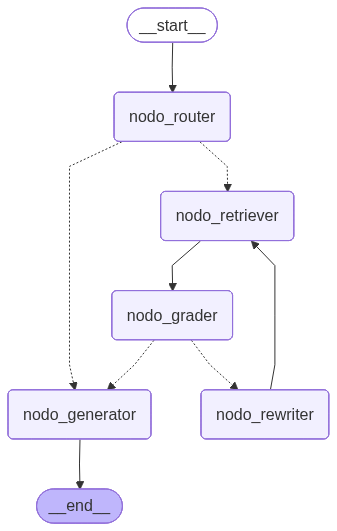

In [25]:
# Visualizar el grafo compilado
# Requiere graphviz — si no está disponible se omite sin error
try:
    from IPython.display import Image, display
    display(Image(agente.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f'Visualización no disponible: {e}')
    print('El grafo está compilado correctamente — la visualización es opcional.')

## 7. Evaluación con preguntas de prueba

In [26]:
def ejecutar_agente(pregunta: str) -> dict:
    """Ejecuta el agente con una pregunta y devuelve el estado final.

    Args:
        pregunta: consulta en lenguaje natural.

    Returns:
        Estado final del grafo con la respuesta y metadatos de ejecución.
    """
    estado_inicial = {
        'pregunta'         : pregunta,
        'query_reescrita'  : '',
        'ruta'             : '',
        'chunks'           : [],
        'chunks_relevantes': False,
        'intentos'         : 0,
        'respuesta'        : '',
    }
    return agente.invoke(estado_inicial)


print('Función de ejecución definida.')

Función de ejecución definida.


In [27]:
# Conjunto de preguntas de prueba con tres categorías
# que cubren los tres caminos posibles del grafo
PREGUNTAS_PRUEBA = [
    # paper_especifico — requieren información del ChromaDB
    {
        'pregunta' : 'What is the yield of AuL9 in the synthesis described in the paper?',
        'ruta_esperada': 'paper_especifico',
    },
    {
        'pregunta' : 'What concentration of AuL9 causes nearly 100% inhibition of proliferation?',
        'ruta_esperada': 'paper_especifico',
    },
    # general — respondibles con conocimiento general de química
    {
        'pregunta' : 'What is an N-heterocyclic carbene?',
        'ruta_esperada': 'general',
    },
    {
        'pregunta' : 'What is apoptosis?',
        'ruta_esperada': 'general',
    },
    # fuera_dominio — no relacionadas con química
    {
        'pregunta' : 'What is the capital of Germany?',
        'ruta_esperada': 'fuera_dominio',
    },
]

print(f'Preguntas de prueba: {len(PREGUNTAS_PRUEBA)}')
for i, p in enumerate(PREGUNTAS_PRUEBA):
    print(f'  [{i+1}] [{p["ruta_esperada"]}] {p["pregunta"][:60]}...')

Preguntas de prueba: 5
  [1] [paper_especifico] What is the yield of AuL9 in the synthesis described in the ...
  [2] [paper_especifico] What concentration of AuL9 causes nearly 100% inhibition of ...
  [3] [general] What is an N-heterocyclic carbene?...
  [4] [general] What is apoptosis?...
  [5] [fuera_dominio] What is the capital of Germany?...


In [28]:
# Ejecutar el agente con todas las preguntas de prueba
# y registrar los resultados para el resumen final
resultados_prueba = []

for i, item in enumerate(PREGUNTAS_PRUEBA):
    print(f'\n{"-"*65}')
    print(f'PREGUNTA {i+1}: {item["pregunta"]}')
    print(f'Ruta esperada: {item["ruta_esperada"]}')
    print(f'{"-"*65}')

    estado_final = ejecutar_agente(item['pregunta'])

    ruta_correcta = estado_final['ruta'] == item['ruta_esperada']
    print(f'Ruta asignada : {estado_final["ruta"]} '
          f'{"✓" if ruta_correcta else "✗"}')
    print(f'Intentos      : {estado_final["intentos"]}')
    print(f'Respuesta     : {estado_final["respuesta"][:200]}...')

    resultados_prueba.append({
        'pregunta'     : item['pregunta'],
        'ruta_esperada': item['ruta_esperada'],
        'ruta_asignada': estado_final['ruta'],
        'ruta_correcta': ruta_correcta,
        'intentos'     : estado_final['intentos'],
        'respuesta'    : estado_final['respuesta'],
    })

aciertos = sum(1 for r in resultados_prueba if r['ruta_correcta'])
print(f'\nRouter accuracy: {aciertos}/{len(PREGUNTAS_PRUEBA)} '
      f'({100*aciertos/len(PREGUNTAS_PRUEBA):.0f}%)')


-----------------------------------------------------------------
PREGUNTA 1: What is the yield of AuL9 in the synthesis described in the paper?
Ruta esperada: paper_especifico
-----------------------------------------------------------------
  [Router] Ruta asignada: paper_especifico


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00,  2.43it/s]


  [Retriever] 4 chunks recuperados para: What is the yield of AuL9 in the synthesis described in the ...
  [Grader] Chunks relevantes: True
  [Generator] Respuesta generada (65 chars)
Ruta asignada : paper_especifico ✓
Intentos      : 0
Respuesta     : The yield of AuL9 in the synthesis described in the paper is 47%....

-----------------------------------------------------------------
PREGUNTA 2: What concentration of AuL9 causes nearly 100% inhibition of proliferation?
Ruta esperada: paper_especifico
-----------------------------------------------------------------
  [Router] Ruta asignada: paper_especifico


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


  [Retriever] 4 chunks recuperados para: What concentration of AuL9 causes nearly 100% inhibition of ...
  [Grader] Chunks relevantes: True
  [Generator] Respuesta generada (87 chars)
Ruta asignada : paper_especifico ✓
Intentos      : 0
Respuesta     : The concentration of AuL9 that causes nearly 100% inhibition of proliferation is 50 mM....

-----------------------------------------------------------------
PREGUNTA 3: What is an N-heterocyclic carbene?
Ruta esperada: general
-----------------------------------------------------------------
  [Router] Ruta asignada: general
  [Generator] Respuesta generada (1433 chars)
Ruta asignada : general ✓
Intentos      : 0
Respuesta     : An **N-heterocyclic carbene (NHC)** is a type of **carbene** — a molecule with a carbon atom bonded to two substituents and having two non-bonding electrons in a lone pair — that is stabilized by bein...

-----------------------------------------------------------------
PREGUNTA 4: What is apoptosis?
Ruta espera

## 8. Resumen final

In [29]:
aciertos      = sum(1 for r in resultados_prueba if r['ruta_correcta'])
total         = len(resultados_prueba)
con_retriever = sum(1 for r in resultados_prueba if r['ruta_asignada'] == 'paper_especifico')
con_rewriter  = sum(1 for r in resultados_prueba if r['intentos'] > 0)

print('=' * 60)
print('RESUMEN — AGENTE RAG LANGGRAPH COMPLETADO')
print('=' * 60)
print(f'  Preguntas evaluadas   : {total}')
print(f'  Router accuracy       : {aciertos}/{total} ({100*aciertos/total:.0f}%)')
print(f'  Rutas via ChromaDB    : {con_retriever}')
print(f'  Activaciones Rewriter : {con_rewriter}')
print(f'  Colección ChromaDB    : {COLECCION} ({coleccion.count()} docs)')
print(f'  Modelo LLM            : {MODELO_LLM}')
print(f'  Modelo embeddings     : {MODELO_EMBED}')
print('=' * 60)
print('Siguiente paso: migrar a src/agent/graph.py y exponer')
print('como endpoint POST /agent_query en la API FastAPI')
print('=' * 60)

RESUMEN — AGENTE RAG LANGGRAPH COMPLETADO
  Preguntas evaluadas   : 5
  Router accuracy       : 5/5 (100%)
  Rutas via ChromaDB    : 2
  Activaciones Rewriter : 0
  Colección ChromaDB    : chem_rag_pmc10967698 (77 docs)
  Modelo LLM            : Qwen/Qwen3-8B
  Modelo embeddings     : BAAI/bge-m3
Siguiente paso: migrar a src/agent/graph.py y exponer
como endpoint POST /agent_query en la API FastAPI
